# Music Genre Predictor
### Introduction:
This project investigates whether a song's genre can be predicted by its audio features. The project uses a Kaggle dataset of 114,000 songs from music streaming platform Spotify. I have focused this project on trying to identify 8 distinct and popular genres in order to avoid diluting the accuracy of the model by including similar genres and subgenres.

This project was built as part of a self-directed study programme in data science

### Key Findings:
* I was able to create a model that predicts a song's genre with a 73% accuracy.
* Classical music was the easiest to predict out of the selected genres, with a 88% precision in the final model.
* Acoustic and pop were the most difficult genres for the model to distinguish between, likely due to the high variance of sound found within them
* A song's acousticness was the most important feature in identifying its genre



In [64]:
import pandas as pd
df = pd.read_csv('/content/dataset.csv',index_col=0)
# filters the dataset to 8 distinct genres out of the original 125
selected_genres = ['classical', 'hip-hop', 'metal', 'jazz', 'pop', 'acoustic', 'edm', 'country']
df = df[df['track_genre'].isin(selected_genres)]
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


The original dataset includes 20 columns, which contain metadata of each song (track_id, artists, album_name, etc) as well as audio features (danceability, energy, loudness, etc).

The dataset has been stripped back to only include the 8 genres in the selected_genres list. This makes the classification of each genre simpler as our selected set are all audibly very different, whereas the original dataset lists 125 genres, some of which are subgenres of others

## Data Cleaning

In [65]:
# drops rows that are completely identical
print(f'There are {df.duplicated().sum()} duplicate rows')
df=df.drop_duplicates()

# shows the tracks that have the same track id but different genre
print(f'After removing duplicates, there are {df.duplicated(subset=['track_id']).sum()} rows with the same track_id but different genre')
duplicate_track_id=df[df['track_id'].duplicated(keep=False)].sort_values(by='track_id')
print("\n Sample of 3 songs with conflicting genres: \n")
print(duplicate_track_id[['track_name','artists','track_genre']].head(6))
df=df.drop_duplicates(subset=['track_id'], keep=False)

# removed columns that do not represent audio features
columns_to_drop = ['track_id','artists','album_name','track_name','popularity']
df = df.drop(columns=['track_id', 'artists', 'album_name', 'track_name', 'popularity'])


There are 93 duplicate rows
After removing duplicates, there are 176 rows with the same track_id but different genre

 Sample of 3 songs with conflicting genres: 

                track_name                  artists track_genre
81361              FRIENDS    Marshmello;Anne-Marie         pop
30009              FRIENDS    Marshmello;Anne-Marie         edm
81966  Dirty Little Secret  Zack Knight;Nora Fatehi         pop
51156  Dirty Little Secret  Zack Knight;Nora Fatehi     hip-hop
81407  Love Me Like You Do           Ellie Goulding         pop
30002  Love Me Like You Do           Ellie Goulding         edm


This gives us quite interesting information, as there are more rows with the same track id than identical rows. After exploring this further, it became apparent that some tracks are featured twice but with different genres, so I was left with a decision to make on how to treat these.

I decided it is best to remove all instances of the song in order to avoid feeding the training data the exact same audio features with different genres, which may confuse the model (as clearly the creator of the dataset is unable to decide on the correct genre either).

I also made the decision to drop the popularity column, as although genre effects popularity, I want the model to be based purely on audio features, not on streaming statistics.

## Exploratory Data Analysis

<Axes: xlabel='loudness', ylabel='valence'>

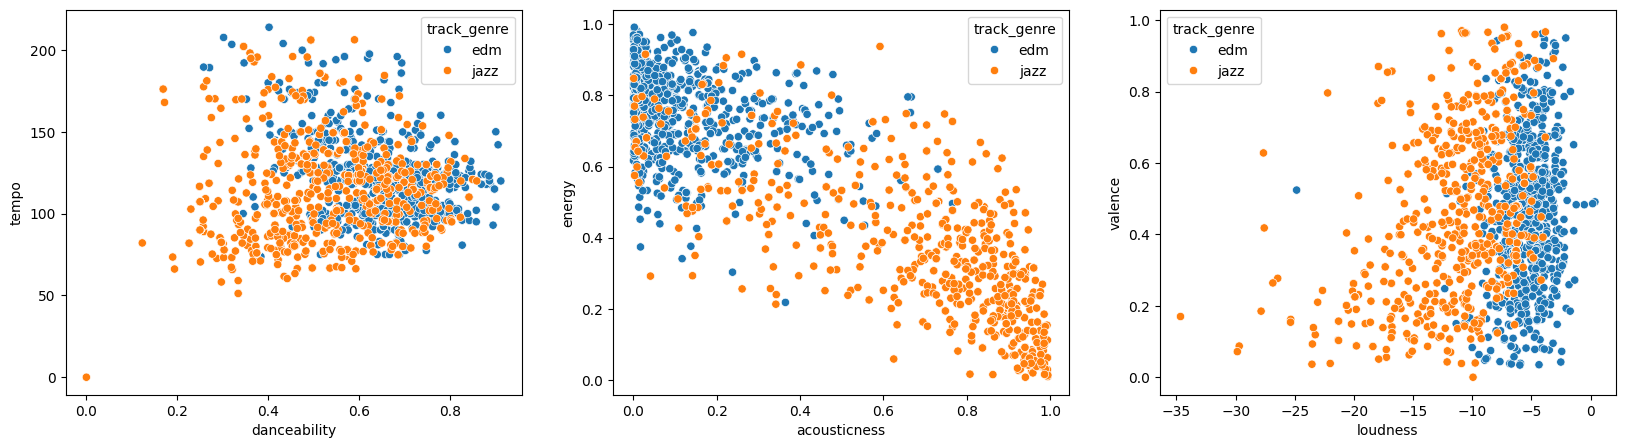

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# creates a dataframe containing only jazz and edm tracks
jazz_vs_edm = df[df['track_genre'].isin(['jazz','edm'])]

fig, axes = plt.subplots(1,3, figsize=(20,5))

# creates 3 scatterplots comparing various audio features between jazz and edm music
sns.scatterplot(
    data=jazz_vs_edm,
    x='danceability',
    y='tempo',
    hue='track_genre',
    ax=axes[0]
)
sns.scatterplot(
    data=jazz_vs_edm,
    x='acousticness',
    y='energy',
    hue='track_genre',
    ax=axes[1]
)
sns.scatterplot(
    data=jazz_vs_edm,
    x='loudness',
    y='valence',
    hue='track_genre',
    ax=axes[2]
)

As you can see in the scatterplots above, some audio features distinguish between genres better than others. When comparing edm and jazz only, it is apparent that they have a similar tempo and danceability, but their energy and accousticness are more distinct from each other.

Now lets explore how different features of a song vary between all genres, and which features appear to be the most important from inspecting the plots.

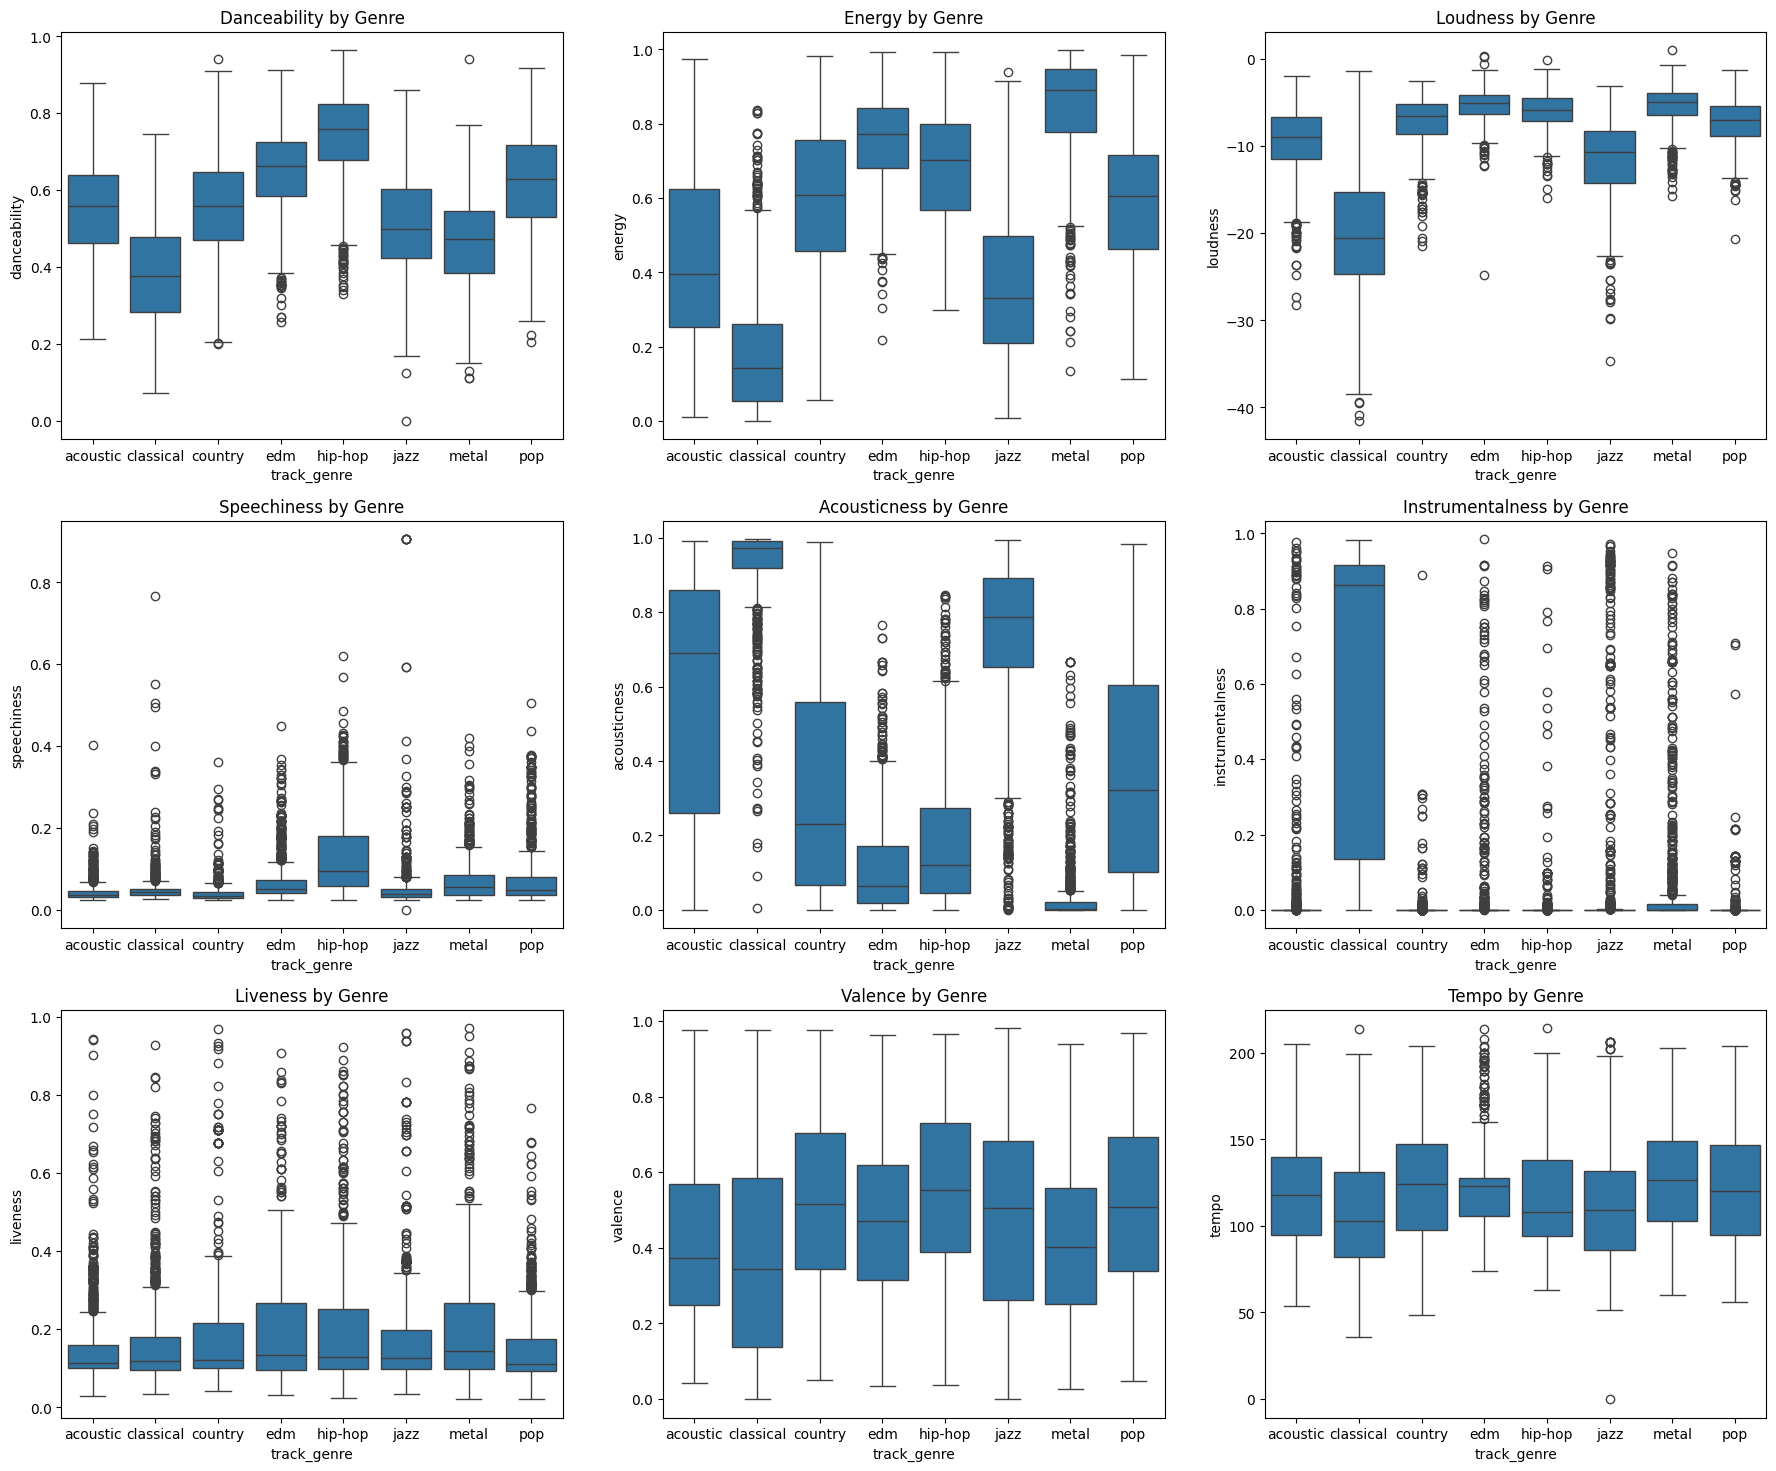

In [67]:
fig, axes = plt.subplots(3,3, figsize=(22,18))
features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

# creates 9 boxplots comparing various audio features between all of our selected genres
for index in range(0,9):
    sns.boxplot(
        data=df,
        x='track_genre',
        y=features[index],
        ax = axes[index // 3, index % 3]
    )
    axes[index // 3, index % 3].set_title(f'{features[index].capitalize()} by Genre')

As visualised above, some values of musical features are more indicative of genres than others. Liveness, valence, and tempo all appear to be similar regardless of genre. On the other hand, an instrumentallness of above 0.2 appears to strongly indicate the music is classical, a speechinesss of above 0.15 strongly indicates hip-hop, and an acousticness of 0 would indicate metal.
These patterns can be used by our model to help predict the genre just by the audio features.


## Preparing Data For Modelling

In [68]:
from sklearn.model_selection import train_test_split

y=df.track_genre
X=df.drop(['track_genre'], axis=1)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)

## converts the explicit column from boolean values to integers so model can read values
X_train_explicit_fix = pd.DataFrame(X_train.explicit.astype(int))
X_valid_explicit_fix = pd.DataFrame(X_valid.explicit.astype(int))

## combines the categorical data with the numerical data again
X_train = pd.concat([X_train_explicit_fix, X_train.drop(['explicit'],axis=1)],axis=1)
X_valid = pd.concat([X_valid_explicit_fix, X_valid.drop(['explicit'],axis=1)],axis=1)


## Building The First Model

Precision score for first model is 0.6362433862433863 

              precision    recall  f1-score   support

    acoustic       0.47      0.44      0.45       204
   classical       0.79      0.82      0.81       176
     country       0.63      0.65      0.64       206
         edm       0.65      0.68      0.67       190
     hip-hop       0.63      0.58      0.61       188
        jazz       0.68      0.75      0.71       192
       metal       0.75      0.74      0.74       178
         pop       0.48      0.45      0.46       178

    accuracy                           0.64      1512
   macro avg       0.64      0.64      0.64      1512
weighted avg       0.63      0.64      0.63      1512



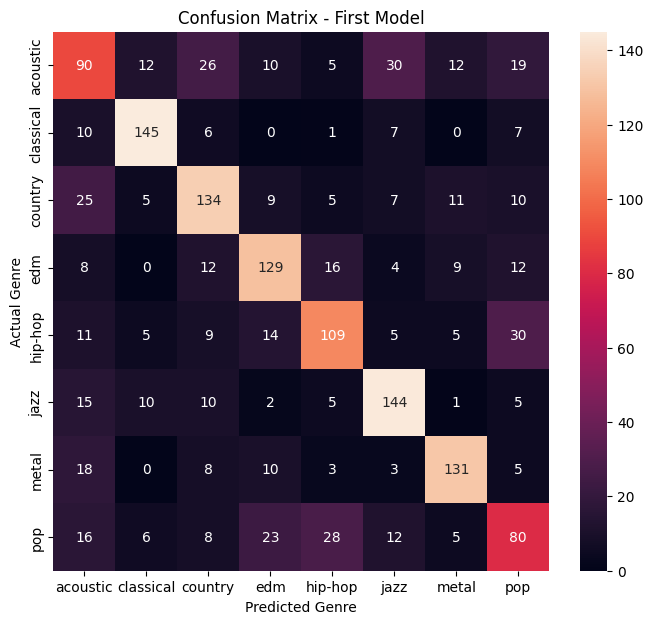

In [69]:
from sklearn.tree import DecisionTreeClassifier

# fits the model, and predicts X_valid with it
music_model=DecisionTreeClassifier(random_state=0)
music_model.fit(X_train, y_train)
predictions = music_model.predict(X_valid)

# displays the precision and recall for each genre individually
from sklearn.metrics import accuracy_score

print(f'Precision score for first model is {accuracy_score(y_valid, predictions)} \n')
from sklearn.metrics import classification_report
print(classification_report(y_valid, predictions))

# displays a heat map showing the accuracy of the model, and where it is making mistakes
from sklearn.metrics import confusion_matrix
first_model_matrix = confusion_matrix(y_valid, predictions)
plt.figure(figsize = (8,7))
sns.heatmap(first_model_matrix,
            annot=True,
            fmt='d',
            xticklabels=music_model.classes_,
            yticklabels=music_model.classes_)
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.title('Confusion Matrix - First Model')
plt.show()

According to our classification report, the genre easiest to predict is classical. This makes sense as when viewing the distribution of features over each genre, classical was significantly different in its distribution in energy, loudness, acousticness, and instrumentalness.The errors in classical music therefore must have come by fairly anomalous results.


The hardest to predict genres are pop and acoustic, perhaps this tells us that these genres have a greater variety of sound, and are therefore harder to pinpoint

Our heatmap seems to indicate hip-hop and pop are the genres that our model is confusing the most

## Building The Improved Model

Precision score for second model is 0.7268518518518519 

              precision    recall  f1-score   support

    acoustic       0.54      0.63      0.58       177
   classical       0.88      0.87      0.87       177
     country       0.72      0.72      0.72       205
         edm       0.82      0.72      0.77       215
     hip-hop       0.73      0.71      0.72       193
        jazz       0.82      0.79      0.81       199
       metal       0.83      0.76      0.79       196
         pop       0.49      0.59      0.54       150

    accuracy                           0.73      1512
   macro avg       0.73      0.72      0.72      1512
weighted avg       0.74      0.73      0.73      1512



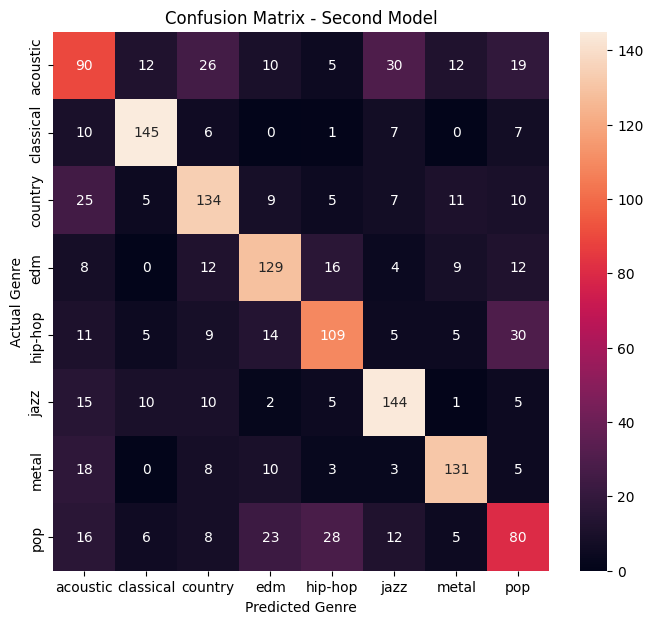

In [70]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# fits the model, and predicts X_valid with it, uses a label encoder as XGBClassifier cannot handle categorical data by default
music_model_xgb = XGBClassifier(n_estimators=500,
                                random_state=0,
                                early_stopping_rounds=5,)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)
music_model_xgb.fit(X_train, y_train_encoded,
                    eval_set=[(X_valid, y_valid_encoded)],
                    verbose=False)
predictions_encoded = music_model_xgb.predict(X_valid)
predictions_xgb = label_encoder.inverse_transform(predictions_encoded)

# displays the precision and recall for each genre individually
print(f'Precision score for second model is {accuracy_score(y_valid, predictions_xgb)} \n')
print(classification_report(predictions_xgb,y_valid))

# displays a heat map showing the accuracy of the model, and where it is making mistakes
second_model_matrix = confusion_matrix(y_valid, predictions)
plt.figure(figsize = (8,7))
sns.heatmap(second_model_matrix,
            annot=True,
            fmt='d',
            xticklabels=music_model.classes_,
            yticklabels=music_model.classes_)
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.title('Confusion Matrix - Second Model')
plt.show()

This second model shows a significant improvement, with a precision score of 0.7269 compared to the first model's 0.6362.

There is an interesting dispartity between precision and recall of edm. Clearly, when the model believes a song is edm it is correct 82% of the time, but it is only recognising a truly edm song 72% of the time. Pop also has a 10% difference in precision and recall, but as the genre with the lowest precision, it is relatively not as significant as the edm disparity. We can see that it is often classifying edm music as pop music (23 times), but  pop music is mistaken for hip hop and acoustic more often than edm.

## Feature Importance

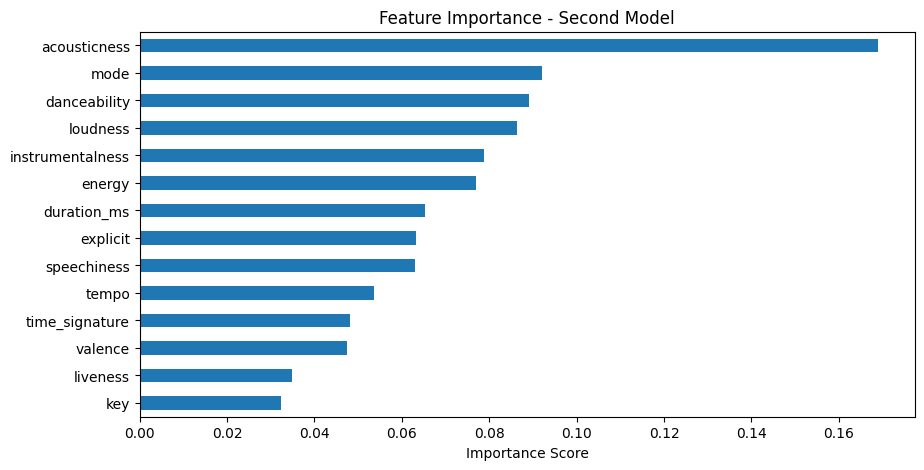

In [71]:
# gets feature importances and plots them in a bar graph
importance = pd.Series(music_model_xgb.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind='barh', figsize=(10, 5))
plt.title('Feature Importance - Second Model')
plt.xlabel('Importance Score')
plt.show()

As we can see, acousticness is the most important feature our xgboost model is using for its predictions. This is not surprising considering we observed the distribution of acousticness being fairly different for all genres when we plotted our boxplots.

I naively thought that mode would not be particularly relevant (so much so that I did not plot a boxplot for it), as mode could only be 1 or 0, so a particular mode could not be unique to a genre. However as we can see it is the second most important feature. Perhaps certain genres like classical and jazz favour minor keys, while pop and EDM tend toward major keys, assisting the model more than I would have predicted.

Looking at the boxplots again, I would have expected energy to be a more deciding factor, as the distributions are quite different for different genres, although looking at it again, there are few outliers as the range for each genre generally covers most of the sample space.

## Conclusion

This project shows that the audio features of a song can be used to predict its genre reasonably accurately. Classical music was the model's most successful genre to predict, and pop music its least successful. This is likely down to the distinctness of classical compared to the other genres, while pop can encompass a wide variety of different sounds.

Acousticness appeared to be the most important feature of a track in predicting its genre. The mode of a track contributed surprisingly highly to the prediction model for a feature with only two possibilities.

### Limitations

The model's accuracy will have been negatively affected by the smaller sample size. Despite the dataset being large, after focusing our attention to 8 genres and removing tracks that feature multiple times, most genres were only tested on ~190 tracks each. Pop music was only trained on 150, the lowest of all genres, which may have contributed to the model's lower prediction accuracy.

Another limitation is the genuine subjective nature of a song's genre. We observed that there were many songs entered into the dataset more than once under different genres. This shows us that even Spotify are unable to pinpoint the genre of many songs, and if this is the case how can we expect our model to. Perhaps some of the 'incorrect' predictions by the model could arguably be correct, and maybe there are deeper questions about whether the audio features of a track not only can be used to predict its genre, but themselves define its genre.